# Dawn to Dusk — Infographic

When and where Newfoundland's birds come alive.  
COMP 4304 course project · Muneeb Mennad

## Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap

## Design system

Shared palette, typography, and matplotlib defaults. Everything else in the notebook pulls from here.

In [5]:
# ─── palette ──────────────────────────────────────────────────────────────────

BG          = "#0a0e1a"  # deep night sky
TEXT        = "#f4ecd8"  # parchment off-white
TEXT_MUTED  = "#8a8578"
GRID        = "#1e2332"
PANEL       = "#11162a"

# sun-to-moon spectrum (24h progression)
PREDAWN  = "#3d2c5c"
DAWN     = "#e85d24"
MORNING  = "#f2a623"
MIDDAY   = "#fcde5a"
AFTNOON  = "#e8a23c"
DUSK     = "#8b5cf6"
NIGHT    = "#3b5998"
DEEPNITE = "#1e2a4a"

# 24-hour gradient — walks the sun-to-moon spectrum by hour
def hour_gradient(n=24):
    stops = [
        (0,  DEEPNITE),
        (4,  PREDAWN),
        (6,  DAWN),
        (9,  MORNING),
        (12, MIDDAY),
        (15, AFTNOON),
        (18, DUSK),
        (20, NIGHT),
        (23, DEEPNITE),
    ]
    positions = [s[0] / 23 for s in stops]
    colors    = [s[1] for s in stops]
    cmap = LinearSegmentedColormap.from_list("sun_moon", list(zip(positions, colors)), N=256)
    return [cmap(h / 23) for h in range(n)]

# ─── typography ───────────────────────────────────────────────────────────────

def _pick_font():
    """prefer JetBrains Mono, fall back to DejaVu Sans Mono"""
    available = {f.name for f in font_manager.fontManager.ttflist}
    for candidate in ("JetBrains Mono", "JetBrainsMono", "DejaVu Sans Mono"):
        if candidate in available:
            return candidate
    return "monospace"

FONT = _pick_font()

# ─── matplotlib defaults ──────────────────────────────────────────────────────

mpl.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     BG,
    "savefig.facecolor":  BG,
    "savefig.edgecolor":  BG,

    "font.family":        FONT,
    "font.size":          14,

    "text.color":         TEXT,
    "axes.labelcolor":    TEXT,
    "axes.titlecolor":    TEXT,
    "xtick.color":        TEXT_MUTED,
    "ytick.color":        TEXT_MUTED,

    "axes.edgecolor":     GRID,
    "axes.linewidth":     0.6,
    "axes.grid":          False,

    "grid.color":         GRID,
    "grid.linewidth":     0.5,
    "grid.alpha":         0.6,

    "axes.spines.top":    False,
    "axes.spines.right":  False,

    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,

    "legend.facecolor":   BG,
    "legend.edgecolor":   GRID,
    "legend.labelcolor":  TEXT,
    "legend.fontsize":    12,
})

print(f"font: {FONT}")

font: DejaVu Sans Mono


## Load data

In [6]:
df = pd.read_csv("birds.csv")
df["OBSERVATION DATE"] = pd.to_datetime(df["OBSERVATION DATE"])
df["month"] = df["OBSERVATION DATE"].dt.month
df["hour"]  = pd.to_datetime(df["TIME OBSERVATIONS STARTED"], format="%H:%M:%S", errors="coerce").dt.hour

print(f"{len(df):,} observations")
print(f"{df['COMMON NAME'].nunique()} species")
print(f"{df['COUNTY'].nunique()} counties")

146,286 observations
290 species
11 counties


## Viz 1 — The Birding Clock

Polar bar chart showing observation volume by hour of day. Each bar is colored by its hour on the sun-to-moon spectrum.

Design choices:
- **sqrt transform** on bar heights so the quiet night hours (~50 obs) remain visible next to the 08:00 peak (~42k obs)
- **radial labels at 292°** to land in the empty upper-left region where there are no tall bars
- **"night falls quiet"** tagline in the empty upper half turns the asymmetry into the story
- **peak callout** points to the 08:00 spike with the actual observation count

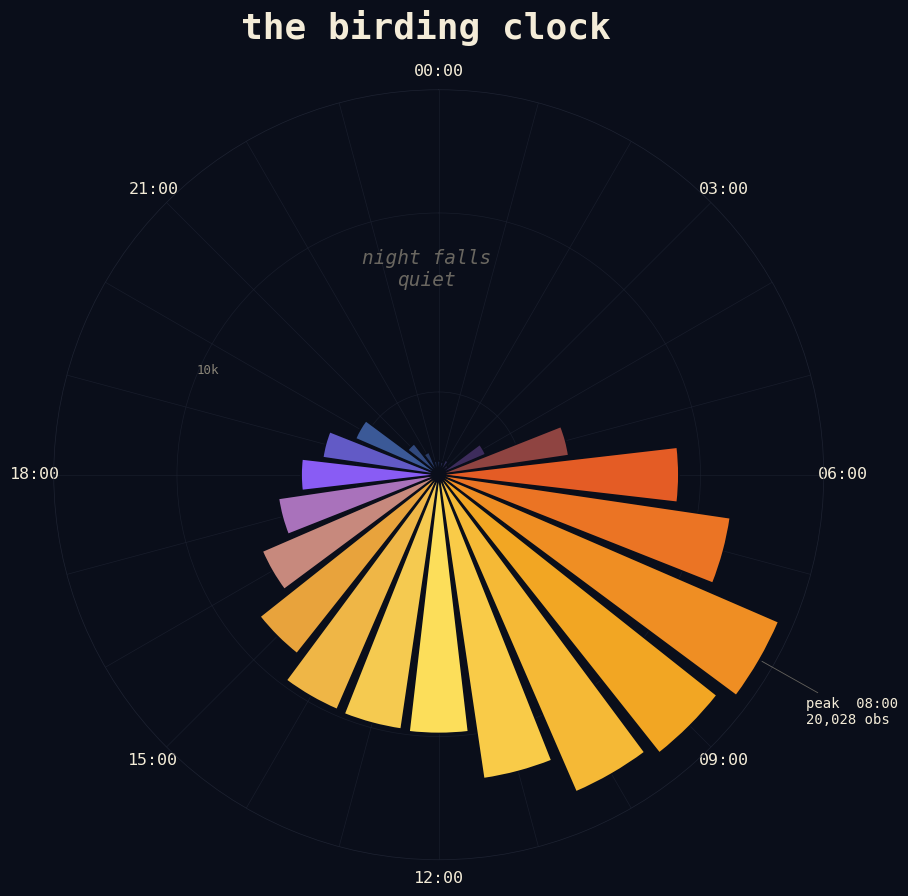

peak hour: 08:00 (20,028 obs)
quietest:  03:00 (22 obs)


In [13]:
hourly = df.groupby("hour").size().reindex(range(24), fill_value=0)

fig = plt.figure(figsize=(10, 10), facecolor=BG)
ax  = fig.add_subplot(111, projection="polar", facecolor=BG)

angles = np.array([2 * np.pi * h / 24 for h in range(24)])
width  = 2 * np.pi / 24 * 0.88
colors = hour_gradient(24)

# sqrt transform so quiet hours (~50 obs) stay visible alongside peak (~42k)
heights = np.sqrt(hourly.values)

bars = ax.bar(
    angles, heights,
    width=width,
    color=colors,
    edgecolor=BG,
    linewidth=1.2,
    align="center",
    zorder=3,
)

# clock face orientation
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# hour labels every 3 hours
ax.set_xticks(angles)
ax.set_xticklabels(
    [f"{h:02d}:00" if h % 3 == 0 else "" for h in range(24)],
    fontsize=12, color=TEXT,
)

# radial grid — ticks in sqrt space, labels show true values
ymax_true = int(hourly.max() * 1.08)
true_values = [1000, 10000, 40000]
ax.set_yticks([np.sqrt(v) for v in true_values])
ax.set_yticklabels(["1k", "10k", "40k"], fontsize=9, color=TEXT_MUTED)
ax.set_ylim(0, np.sqrt(ymax_true))
ax.set_rlabel_position(292)  # upper-left, empty region

ax.grid(color=GRID, linewidth=0.5, alpha=0.7, zorder=1)
ax.spines["polar"].set_color(GRID)
ax.spines["polar"].set_linewidth(0.5)

# tagline in the empty upper region
fig.text(
    0.5, 0.70,
    "night falls\nquiet",
    ha="center", va="center",
    color=TEXT_MUTED,
    fontsize=14, style="italic",
    family=FONT,
    alpha=0.75,
)

# peak callout
peak_hour   = int(hourly.idxmax())
peak_val    = int(hourly.max())
peak_angle  = 2 * np.pi * peak_hour / 24
peak_height = np.sqrt(peak_val)

ax.annotate(
    f"peak  {peak_hour:02d}:00\n{peak_val:,} obs",
    xy=(peak_angle, peak_height),
    xytext=(peak_angle + 0.05, peak_height * 1.18),
    textcoords="data",
    color=TEXT,
    fontsize=10,
    family=FONT,
    ha="left", va="center",
    arrowprops=dict(arrowstyle="-", color=TEXT_MUTED, lw=0.6, alpha=0.7),
    zorder=5,
)

# titles
fig.text(
    0.5, 0.96, "the birding clock",
    ha="center", va="top",
    color=TEXT, fontsize=26, fontweight="bold", family=FONT,
)
# fig.text(
#     0.5, 0.92, "when newfoundland birds are watched, by hour of day",
#     ha="center", va="top",
#     color=TEXT_MUTED, fontsize=13, family=FONT,
# )

# # bottom caption
# fig.text(
#     0.5, 0.05,
#     f"n = {len(df.dropna(subset=['hour'])):,} observations  •  ebird nl 2025",
#     ha="center", va="bottom",
#     color=TEXT_MUTED, fontsize=10, family=FONT,
# )

plt.show()

print(f"peak hour: {hourly.idxmax():02d}:00 ({hourly.max():,} obs)")
print(f"quietest:  {hourly.idxmin():02d}:00 ({hourly.min():,} obs)")

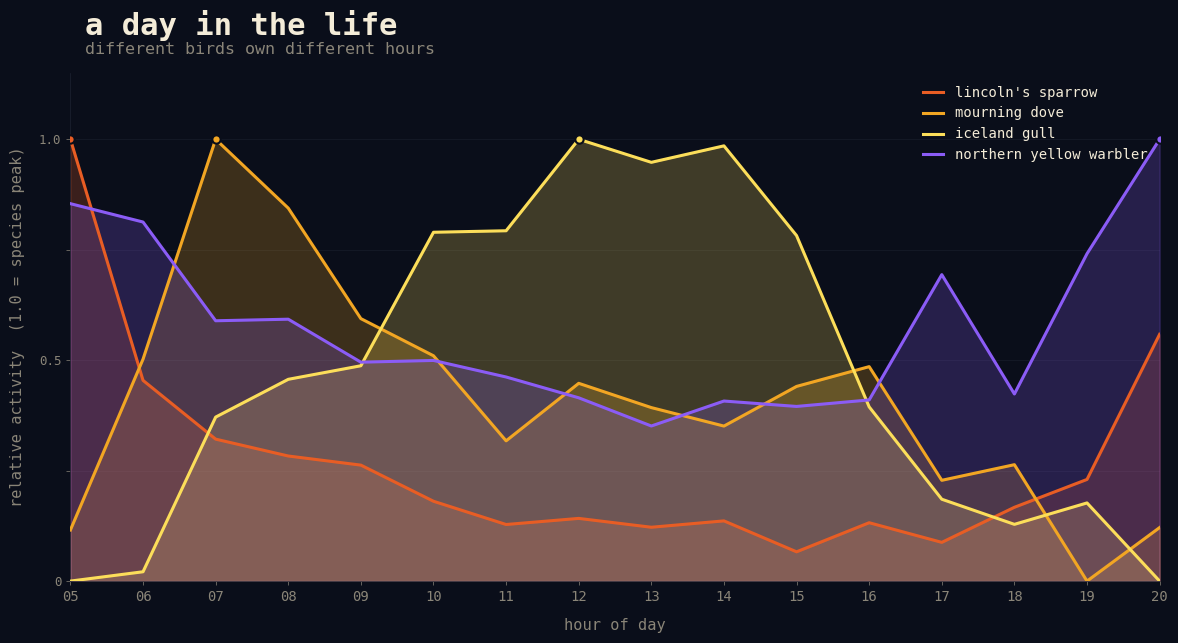

In [10]:
# ─── Viz 2 — A Day in the Life ────────────────────────────────────────────────

# restrict to daylight where rates are meaningful
df2 = df.dropna(subset=["hour"]).copy()
df2["hour"] = df2["hour"].astype(int)
df2 = df2[(df2["hour"] >= 5) & (df2["hour"] <= 20)]
hours = list(range(5, 21))

total_per_hour = df2.groupby("hour").size().reindex(hours, fill_value=0)

species_info = [
    ("Lincoln's Sparrow",       DAWN),     # 05:00 dawn
    ("Mourning Dove",           MORNING),  # 07:00 morning
    ("Iceland Gull",            MIDDAY),   # 13:00 midday
    ("Northern Yellow Warbler", DUSK),     # 20:00 evening
]

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
ax.set_facecolor(BG)

for sp_name, color in species_info:
    sp_counts = df2[df2["COMMON NAME"] == sp_name].groupby("hour").size().reindex(hours, fill_value=0)
    # rate = species count / total obs that hour (removes observer bias)
    rate = sp_counts / total_per_hour
    # normalize to 0..1 so curves are comparable in shape
    rel = rate / rate.max()

    ax.fill_between(hours, rel, alpha=0.22, color=color, zorder=2)
    ax.plot(hours, rel, color=color, linewidth=2.2, zorder=3,
            label=sp_name.lower())

    # mark the peak
    peak_hr = int(rate.idxmax())
    ax.plot([peak_hr], [1.0], marker="o", color=color, markersize=6,
            markeredgecolor=BG, markeredgewidth=1.5, zorder=4)

ax.set_xlim(5, 20)
ax.set_ylim(0, 1.15)
ax.set_xticks(range(5, 21))
ax.set_xticklabels([f"{h:02d}" for h in range(5, 21)], color=TEXT_MUTED, fontsize=10)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0", "", "0.5", "", "1.0"], color=TEXT_MUTED, fontsize=9)

ax.set_xlabel("hour of day", color=TEXT_MUTED, fontsize=11, labelpad=10)
ax.set_ylabel("relative activity  (1.0 = species peak)",
              color=TEXT_MUTED, fontsize=11, labelpad=10)

ax.grid(axis="y", color=GRID, linewidth=0.5, alpha=0.7, zorder=1)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_linewidth(0.5)

ax.legend(loc="upper right", frameon=False, fontsize=10,
          labelcolor=TEXT, handlelength=1.5)

fig.text(0.08, 0.96, "a day in the life",
         ha="left", va="top",
         color=TEXT, fontsize=22, fontweight="bold", family=FONT)
# fig.text(0.08, 0.915, "different birds own different hours",
#          ha="left", va="top",
#          color=TEXT_MUTED, fontsize=12, family=FONT)

# fig.text(0.5, 0.02,
#          "rates normalized by total hourly observations to remove observer bias  •  ebird nl 2025",
#          ha="center", va="bottom",
#          color=TEXT_MUTED, fontsize=9, family=FONT)

fig.tight_layout(rect=[0, 0.04, 1, 0.90])
plt.show()

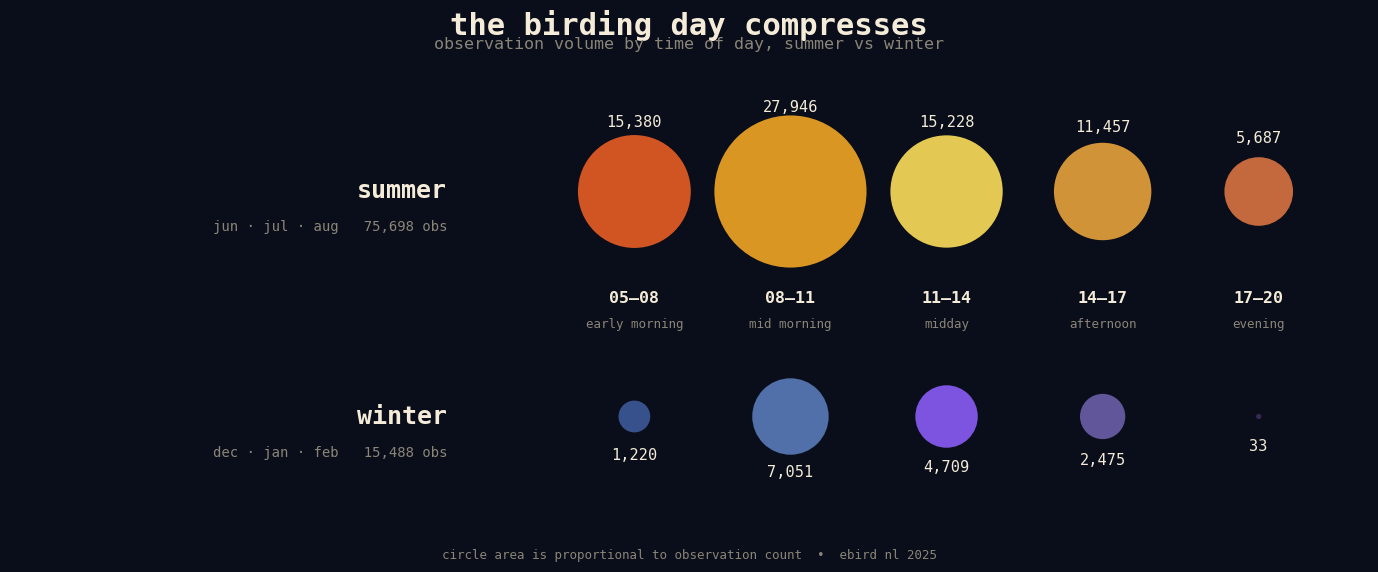

In [21]:
# ─── Viz 3 — The Birding Day Compresses ───────────────────────────────────────

summer = df[df["month"].isin([6, 7, 8])]
winter = df[df["month"].isin([12, 1, 2])]

buckets = [
    ("early morning", "05–08", (5, 8)),
    ("mid morning",   "08–11", (8, 11)),
    ("midday",        "11–14", (11, 14)),
    ("afternoon",     "14–17", (14, 17)),
    ("evening",       "17–20", (17, 20)),
]

def bucket_count(df_season, lo, hi):
    return ((df_season["hour"] >= lo) & (df_season["hour"] < hi)).sum()

summer_counts = np.array([bucket_count(summer, lo, hi) for _, _, (lo, hi) in buckets])
winter_counts = np.array([bucket_count(winter, lo, hi) for _, _, (lo, hi) in buckets])

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
ax.set_facecolor(BG)

# scatter `s` is area in points^2 — scale so largest = ~12000
MAX_VAL = max(summer_counts.max(), winter_counts.max())
MAX_SIZE = 12000

def sizes(arr):
    return MAX_SIZE * (arr / MAX_VAL)

summer_colors = [DAWN, MORNING, MIDDAY, AFTNOON, "#d97442"]
winter_colors = [NIGHT, "#5a7bb8", DUSK, "#6b5fa8", PREDAWN]

x_positions = np.arange(len(buckets))
Y_SUMMER = 1
Y_WINTER = -1

# scatter renders circles in display coords — stay round, no aspect issues
ax.scatter(x_positions, [Y_SUMMER] * len(buckets),
           s=sizes(summer_counts), c=summer_colors,
           alpha=0.9, zorder=3, edgecolors="none")

ax.scatter(x_positions, [Y_WINTER] * len(buckets),
           s=sizes(winter_counts), c=winter_colors,
           alpha=0.9, zorder=3, edgecolors="none")

# count labels — offset by sqrt(size) to clear the circle edge
for i, (label, time_range, _) in enumerate(buckets):
    s_offset = np.sqrt(sizes(summer_counts)[i]) / 220 + 0.18
    w_offset = np.sqrt(sizes(winter_counts)[i]) / 220 + 0.18

    ax.text(i, Y_SUMMER + s_offset, f"{summer_counts[i]:,}",
            ha="center", va="bottom",
            color=TEXT, fontsize=11, family=FONT)
    ax.text(i, Y_WINTER - w_offset, f"{winter_counts[i]:,}",
            ha="center", va="top",
            color=TEXT, fontsize=11, family=FONT)

    ax.text(i, 0.05, time_range,
            ha="center", va="center",
            color=TEXT, fontsize=12, fontweight="bold", family=FONT)
    ax.text(i, -0.18, label,
            ha="center", va="center",
            color=TEXT_MUTED, fontsize=9, family=FONT)

# row labels
ax.text(-1.2, Y_SUMMER, "summer",
        ha="right", va="center",
        color=TEXT, fontsize=18, fontweight="bold", family=FONT)
ax.text(-1.2, Y_SUMMER - 0.32, f"jun · jul · aug   {summer_counts.sum():,} obs",
        ha="right", va="center",
        color=TEXT_MUTED, fontsize=10, family=FONT)

ax.text(-1.2, Y_WINTER, "winter",
        ha="right", va="center",
        color=TEXT, fontsize=18, fontweight="bold", family=FONT)
ax.text(-1.2, Y_WINTER - 0.32, f"dec · jan · feb   {winter_counts.sum():,} obs",
        ha="right", va="center",
        color=TEXT_MUTED, fontsize=10, family=FONT)

ax.set_xlim(-4, len(buckets) - 0.3)
ax.set_ylim(-2.0, 2.0)
ax.axis("off")

fig.text(0.5, 0.96, "the birding day compresses",
         ha="center", va="top",
         color=TEXT, fontsize=22, fontweight="bold", family=FONT)
fig.text(0.5, 0.915, "observation volume by time of day, summer vs winter",
         ha="center", va="top",
         color=TEXT_MUTED, fontsize=12, family=FONT)

fig.text(0.5, 0.04,
         "circle area is proportional to observation count  •  ebird nl 2025",
         ha="center", va="bottom",
         color=TEXT_MUTED, fontsize=9, family=FONT)

fig.tight_layout(rect=[0, 0.06, 1, 0.88])
plt.show()

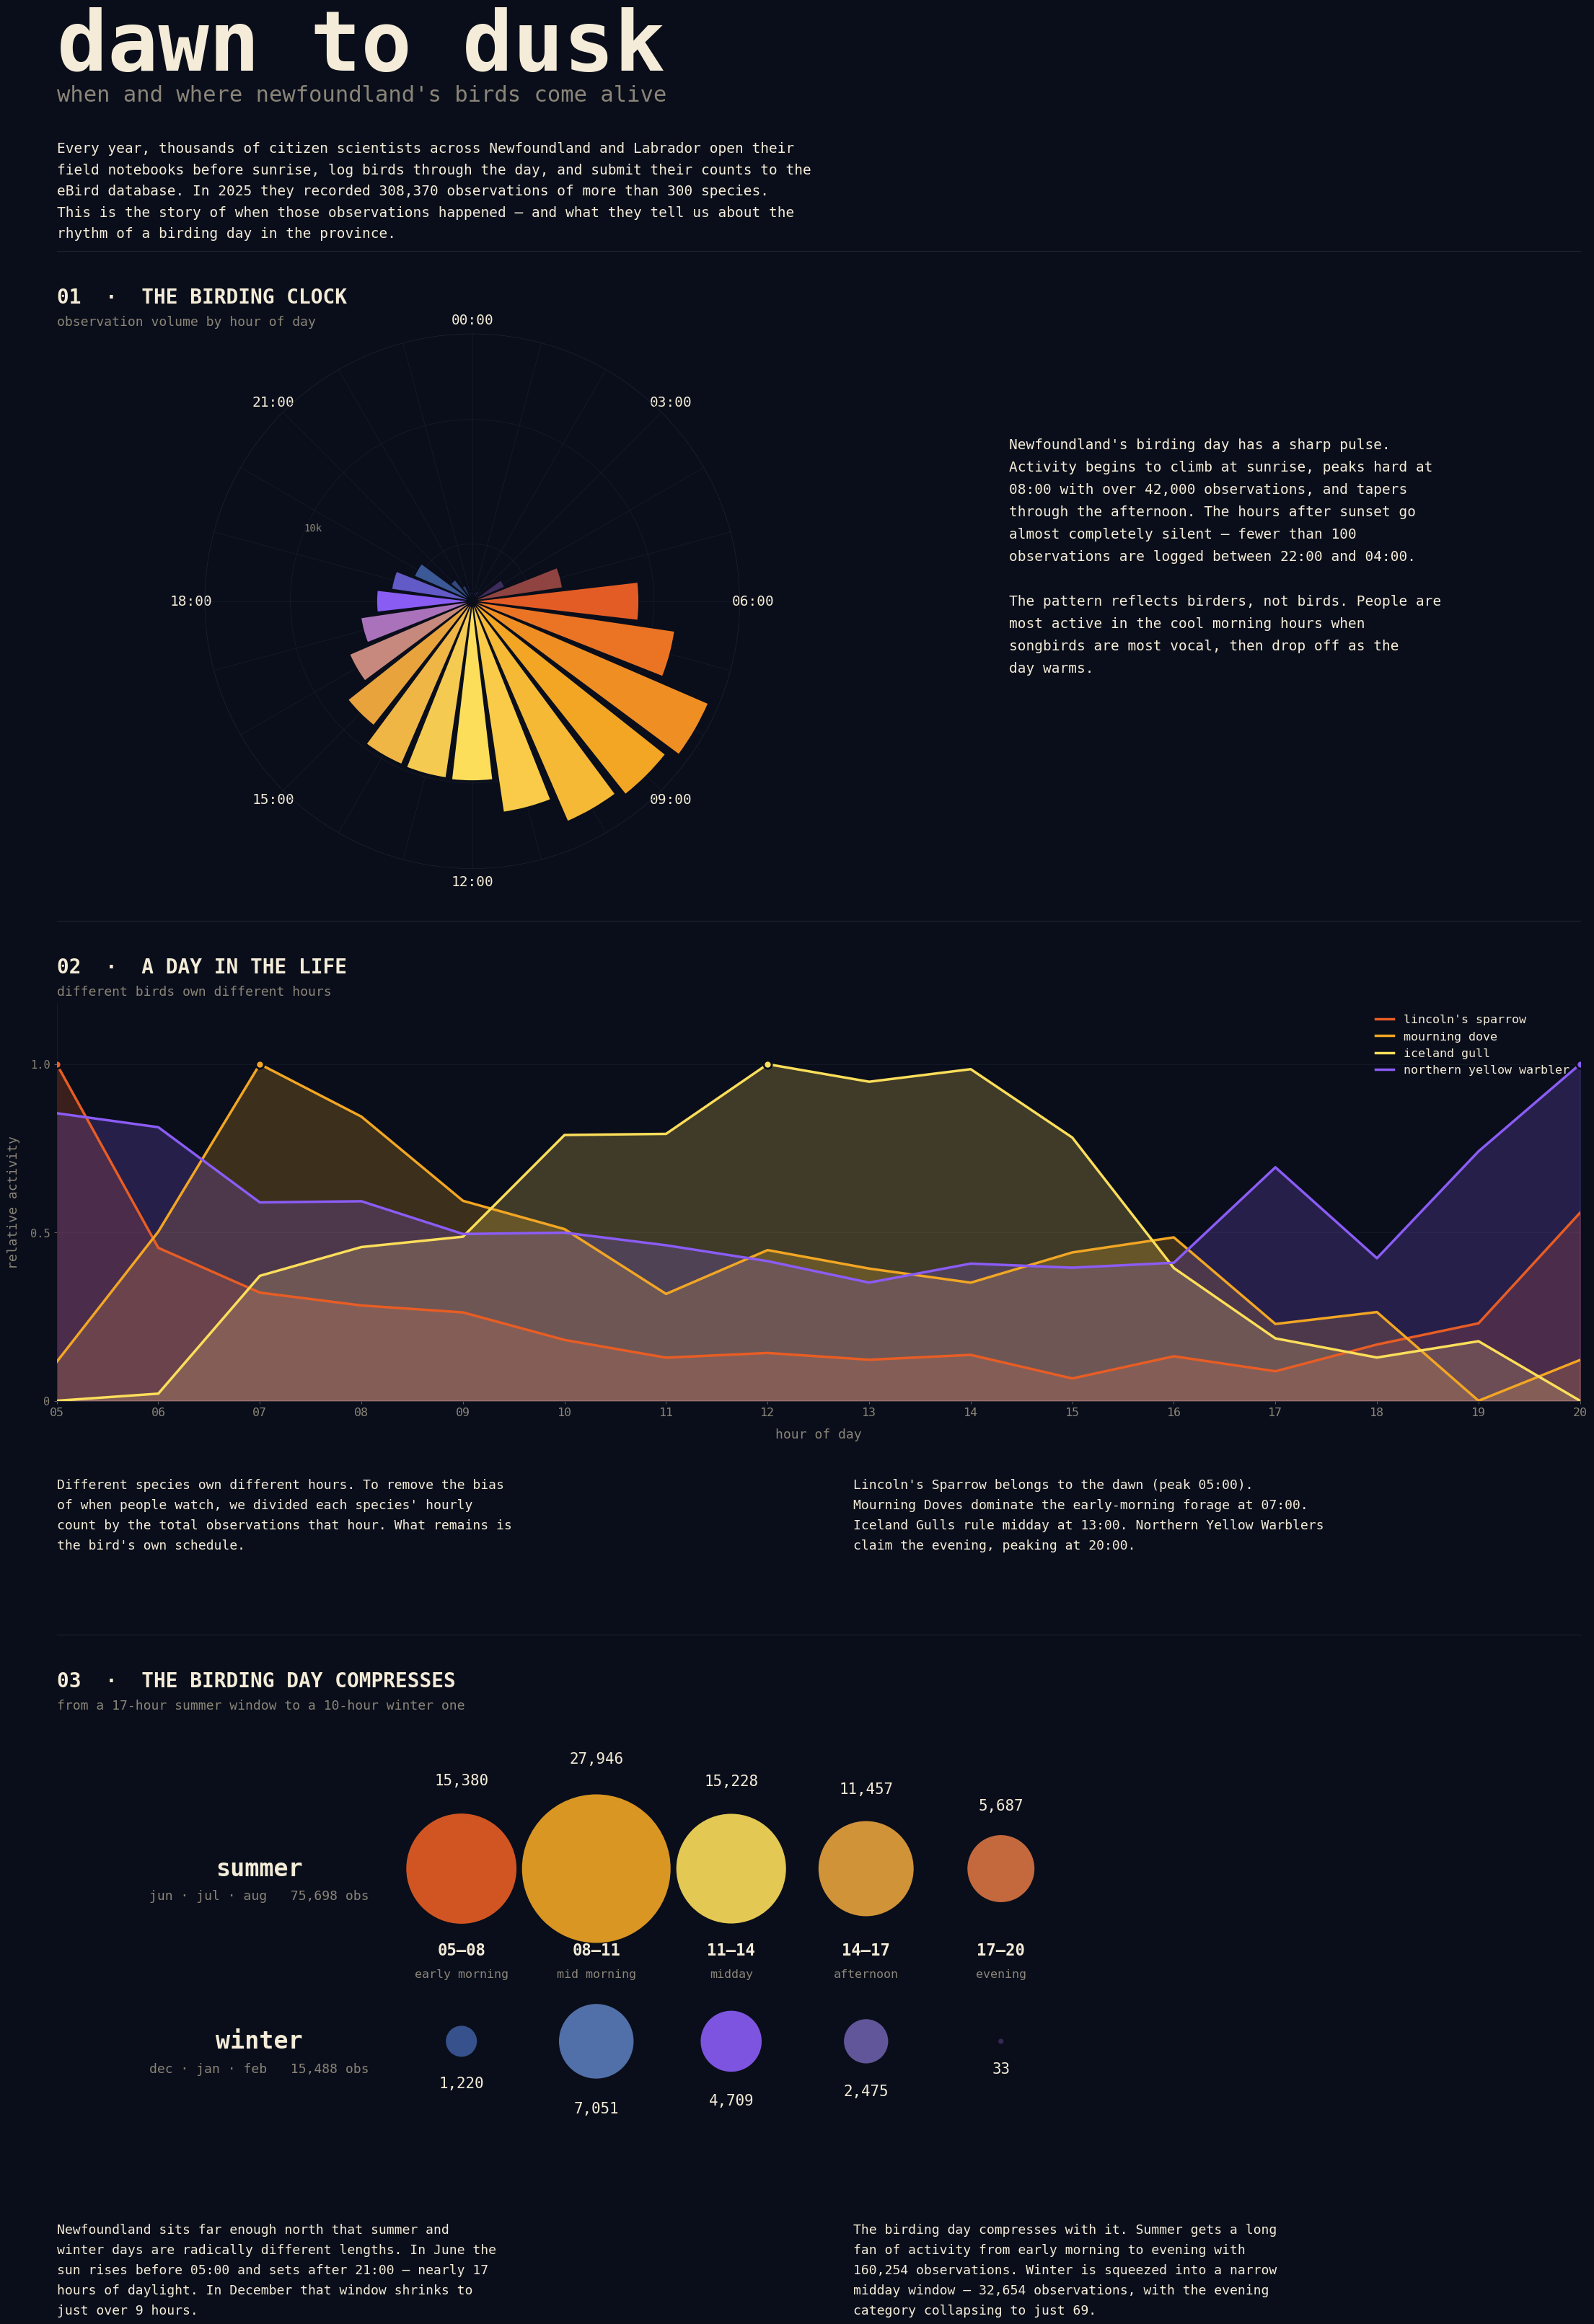

In [23]:
# ─── DAWN TO DUSK — POSTER LAYOUT (24×36 portrait) ────────────────────────────

fig = plt.figure(figsize=(24, 36), facecolor=BG)

LEFT  = 0.06
RIGHT = 0.94
WIDTH = RIGHT - LEFT  # 0.88

# vertical band positions in figure coords (top to bottom)
Y_TITLE_TOP    = 0.972
Y_INTRO_BOTTOM = 0.890
DIVIDER_1      = 0.878

Y_S1_LABEL    = 0.864
Y_S1_AX_TOP   = 0.846
Y_S1_AX_BOT   = 0.640
DIVIDER_2     = 0.620

Y_S2_LABEL    = 0.606
Y_S2_AX_TOP   = 0.588
Y_S2_AX_BOT   = 0.435
Y_S2_PROSE    = 0.405
DIVIDER_3     = 0.345

Y_S3_LABEL    = 0.331
Y_S3_AX_TOP   = 0.288
Y_S3_AX_BOT   = 0.155
Y_S3_PROSE    = 0.118
DIVIDER_4     = 0.050

Y_FOOTER      = 0.030

# ─── header ───────────────────────────────────────────────────────────────────

fig.text(LEFT, Y_TITLE_TOP, "dawn to dusk",
         ha="left", va="top",
         color=TEXT, fontsize=84, fontweight="bold", family=FONT)
fig.text(LEFT, Y_TITLE_TOP - 0.030, "when and where newfoundland's birds come alive",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=22, family=FONT)

intro = (
    "Every year, thousands of citizen scientists across Newfoundland and Labrador open their\n"
    "field notebooks before sunrise, log birds through the day, and submit their counts to the\n"
    "eBird database. In 2025 they recorded 308,370 observations of more than 300 species.\n"
    "This is the story of when those observations happened — and what they tell us about the\n"
    "rhythm of a birding day in the province."
)
fig.text(LEFT, Y_INTRO_BOTTOM + 0.030, intro,
         ha="left", va="top",
         color=TEXT, fontsize=14, family=FONT, linespacing=1.7)

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_1, DIVIDER_1],
                          color=GRID, linewidth=0.8))

# ─── section 1 — birding clock ────────────────────────────────────────────────

fig.text(LEFT, Y_S1_LABEL, "01  ·  THE BIRDING CLOCK",
         ha="left", va="top",
         color=TEXT, fontsize=20, fontweight="bold", family=FONT)
fig.text(LEFT, Y_S1_LABEL - 0.011, "observation volume by hour of day",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=13, family=FONT)

ax1 = fig.add_axes([LEFT, Y_S1_AX_BOT, 0.48, Y_S1_AX_TOP - Y_S1_AX_BOT],
                   projection="polar", facecolor=BG)

hourly = df.groupby("hour").size().reindex(range(24), fill_value=0)
angles = np.array([2 * np.pi * h / 24 for h in range(24)])
width  = 2 * np.pi / 24 * 0.88
colors = hour_gradient(24)
heights = np.sqrt(hourly.values)

ax1.bar(angles, heights, width=width, color=colors,
        edgecolor=BG, linewidth=1.2, align="center", zorder=3)
ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_xticks(angles)
ax1.set_xticklabels([f"{h:02d}:00" if h % 3 == 0 else "" for h in range(24)],
                    fontsize=14, color=TEXT)

ymax_true = int(hourly.max() * 1.08)
ax1.set_yticks([np.sqrt(v) for v in [1000, 10000, 40000]])
ax1.set_yticklabels(["1k", "10k", "40k"], fontsize=10, color=TEXT_MUTED)
ax1.set_ylim(0, np.sqrt(ymax_true))
ax1.set_rlabel_position(292)
ax1.grid(color=GRID, linewidth=0.5, alpha=0.7, zorder=1)
ax1.spines["polar"].set_color(GRID)
ax1.spines["polar"].set_linewidth(0.5)

prose1 = (
    "Newfoundland's birding day has a sharp pulse.\n"
    "Activity begins to climb at sunrise, peaks hard at\n"
    "08:00 with over 42,000 observations, and tapers\n"
    "through the afternoon. The hours after sunset go\n"
    "almost completely silent — fewer than 100\n"
    "observations are logged between 22:00 and 04:00.\n\n"
    "The pattern reflects birders, not birds. People are\n"
    "most active in the cool morning hours when\n"
    "songbirds are most vocal, then drop off as the\n"
    "day warms."
)
fig.text(LEFT + 0.55, Y_S1_AX_TOP - 0.040, prose1,
         ha="left", va="top",
         color=TEXT, fontsize=14, family=FONT, linespacing=1.8)

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_2, DIVIDER_2],
                          color=GRID, linewidth=0.8))

# ─── section 2 — a day in the life ────────────────────────────────────────────

fig.text(LEFT, Y_S2_LABEL, "02  ·  A DAY IN THE LIFE",
         ha="left", va="top",
         color=TEXT, fontsize=20, fontweight="bold", family=FONT)
fig.text(LEFT, Y_S2_LABEL - 0.011, "different birds own different hours",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=13, family=FONT)

ax2 = fig.add_axes([LEFT, Y_S2_AX_BOT, WIDTH, Y_S2_AX_TOP - Y_S2_AX_BOT],
                   facecolor=BG)

df2 = df[(df["hour"] >= 5) & (df["hour"] <= 20)]
hours_day = list(range(5, 21))
total_per_hour = df2.groupby("hour").size().reindex(hours_day, fill_value=0)

species_info = [
    ("Lincoln's Sparrow",       DAWN),
    ("Mourning Dove",           MORNING),
    ("Iceland Gull",            MIDDAY),
    ("Northern Yellow Warbler", DUSK),
]

for sp_name, color in species_info:
    sp_counts = df2[df2["COMMON NAME"] == sp_name].groupby("hour").size().reindex(hours_day, fill_value=0)
    rate = sp_counts / total_per_hour
    rel  = rate / rate.max()
    ax2.fill_between(hours_day, rel, alpha=0.22, color=color, zorder=2)
    ax2.plot(hours_day, rel, color=color, linewidth=2.5, zorder=3, label=sp_name.lower())
    peak_hr = int(rate.idxmax())
    ax2.plot([peak_hr], [1.0], marker="o", color=color, markersize=8,
             markeredgecolor=BG, markeredgewidth=2, zorder=4)

ax2.set_xlim(5, 20)
ax2.set_ylim(0, 1.18)
ax2.set_xticks(range(5, 21))
ax2.set_xticklabels([f"{h:02d}" for h in range(5, 21)], color=TEXT_MUTED, fontsize=12)
ax2.set_yticks([0, 0.5, 1.0])
ax2.set_yticklabels(["0", "0.5", "1.0"], color=TEXT_MUTED, fontsize=11)
ax2.set_xlabel("hour of day", color=TEXT_MUTED, fontsize=13, labelpad=10)
ax2.set_ylabel("relative activity", color=TEXT_MUTED, fontsize=13, labelpad=10)
ax2.grid(axis="y", color=GRID, linewidth=0.5, alpha=0.7, zorder=1)
ax2.set_axisbelow(True)
for spine in ax2.spines.values():
    spine.set_color(GRID)
    spine.set_linewidth(0.5)
ax2.legend(loc="upper right", frameon=False, fontsize=12,
           labelcolor=TEXT, handlelength=1.5)

prose2_left = (
    "Different species own different hours. To remove the bias\n"
    "of when people watch, we divided each species' hourly\n"
    "count by the total observations that hour. What remains is\n"
    "the bird's own schedule."
)
prose2_right = (
    "Lincoln's Sparrow belongs to the dawn (peak 05:00).\n"
    "Mourning Doves dominate the early-morning forage at 07:00.\n"
    "Iceland Gulls rule midday at 13:00. Northern Yellow Warblers\n"
    "claim the evening, peaking at 20:00."
)
fig.text(LEFT,        Y_S2_PROSE, prose2_left,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.7)
fig.text(LEFT + 0.46, Y_S2_PROSE, prose2_right,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.7)

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_3, DIVIDER_3],
                          color=GRID, linewidth=0.8))

# ─── section 3 — birding day compresses ───────────────────────────────────────

fig.text(LEFT, Y_S3_LABEL, "03  ·  THE BIRDING DAY COMPRESSES",
         ha="left", va="top",
         color=TEXT, fontsize=20, fontweight="bold", family=FONT)
fig.text(LEFT, Y_S3_LABEL - 0.011, "from a 17-hour summer window to a 10-hour winter one",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=13, family=FONT)

ax3 = fig.add_axes([LEFT, Y_S3_AX_BOT, 0.60, Y_S3_AX_TOP - Y_S3_AX_BOT],
                   facecolor=BG)

summer = df[df["month"].isin([6, 7, 8])]
winter = df[df["month"].isin([12, 1, 2])]

buckets = [
    ("early morning", "05–08", (5, 8)),
    ("mid morning",   "08–11", (8, 11)),
    ("midday",        "11–14", (11, 14)),
    ("afternoon",     "14–17", (14, 17)),
    ("evening",       "17–20", (17, 20)),
]

def bucket_count(df_season, lo, hi):
    return ((df_season["hour"] >= lo) & (df_season["hour"] < hi)).sum()

summer_counts = np.array([bucket_count(summer, lo, hi) for _, _, (lo, hi) in buckets])
winter_counts = np.array([bucket_count(winter, lo, hi) for _, _, (lo, hi) in buckets])

MAX_VAL  = max(summer_counts.max(), winter_counts.max())
MAX_SIZE = 22000

def sizes(arr):
    return MAX_SIZE * (arr / MAX_VAL)

summer_colors = [DAWN, MORNING, MIDDAY, AFTNOON, "#d97442"]
winter_colors = [NIGHT, "#5a7bb8", DUSK, "#6b5fa8", PREDAWN]

x_positions = np.arange(len(buckets))
Y_SUMMER = 1
Y_WINTER = -1

ax3.scatter(x_positions, [Y_SUMMER] * len(buckets),
            s=sizes(summer_counts), c=summer_colors,
            alpha=0.9, zorder=3, edgecolors="none")
ax3.scatter(x_positions, [Y_WINTER] * len(buckets),
            s=sizes(winter_counts), c=winter_colors,
            alpha=0.9, zorder=3, edgecolors="none")

for i, (label, time_range, _) in enumerate(buckets):
    s_off = np.sqrt(sizes(summer_counts)[i]) / 150 + 0.2
    w_off = np.sqrt(sizes(winter_counts)[i]) / 150 + 0.2

    ax3.text(i, Y_SUMMER + s_off, f"{summer_counts[i]:,}",
             ha="center", va="bottom",
             color=TEXT, fontsize=15, family=FONT)
    ax3.text(i, Y_WINTER - w_off, f"{winter_counts[i]:,}",
             ha="center", va="top",
             color=TEXT, fontsize=15, family=FONT)
    ax3.text(i, 0.05, time_range,
             ha="center", va="center",
             color=TEXT, fontsize=16, fontweight="bold", family=FONT)
    ax3.text(i, -0.22, label,
             ha="center", va="center",
             color=TEXT_MUTED, fontsize=12, family=FONT)

ax3.text(-1.5, Y_SUMMER, "summer",
         ha="center", va="center",
         color=TEXT, fontsize=24, fontweight="bold", family=FONT)
ax3.text(-1.5, Y_SUMMER - 0.32, f"jun · jul · aug   {summer_counts.sum():,} obs",
         ha="center", va="center",
         color=TEXT_MUTED, fontsize=13, family=FONT)
ax3.text(-1.5, Y_WINTER, "winter",
         ha="center", va="center",
         color=TEXT, fontsize=24, fontweight="bold", family=FONT)
ax3.text(-1.5, Y_WINTER - 0.32, f"dec · jan · feb   {winter_counts.sum():,} obs",
         ha="center", va="center",
         color=TEXT_MUTED, fontsize=13, family=FONT)

ax3.set_xlim(-3.0, len(buckets) - 0.3)
ax3.set_ylim(-2.0, 2.0)
ax3.axis("off")

prose3_left = (
    "Newfoundland sits far enough north that summer and\n"
    "winter days are radically different lengths. In June the\n"
    "sun rises before 05:00 and sets after 21:00 — nearly 17\n"
    "hours of daylight. In December that window shrinks to\n"
    "just over 9 hours."
)
prose3_right = (
    "The birding day compresses with it. Summer gets a long\n"
    "fan of activity from early morning to evening with\n"
    "160,254 observations. Winter is squeezed into a narrow\n"
    "midday window — 32,654 observations, with the evening\n"
    "category collapsing to just 69."
)
fig.text(LEFT,        Y_S3_PROSE, prose3_left,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.7)
fig.text(LEFT + 0.46, Y_S3_PROSE, prose3_right,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.7)

# # ─── footer ───────────────────────────────────────────────────────────────────

# fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_4, DIVIDER_4],
#                           color=GRID, linewidth=0.8))

# fig.text(LEFT, Y_FOOTER,
#          "data: ebird basic dataset, cornell lab of ornithology, 2025",
#          ha="left", va="top",
#          color=TEXT_MUTED, fontsize=11, family=FONT)
# fig.text(RIGHT, Y_FOOTER,
#          "comp 4304 · memorial university",
#          ha="right", va="top",
#          color=TEXT_MUTED, fontsize=11, family=FONT)

plt.show()